# Calculating saturation pressure of melt inclusion records

- With the release of the MagmaSat model (Ghiorso and Gualda, 2015; 10.1007/s00410-015-1141-8), incorporating mixed H2O-CO2 fluids into the rhyolite-MELTS framework, calculating melt inclusion saturation pressures through rhyolite-MELTS (v1.2.0) thermodynamic models has become possible.

PetThermoTools uses the rhyolite-MELTS v1.2.0 model to calculate melt inclusion saturation pressures (or the saturation pressure of any melt phase with known H2O and CO2 contents) in 2 separate ways: 

(i) Specified temperature: user provides a known temperature (usually calculated through an empirical thermometer) and `ptt` calculates the pressure of fluid saturation at that give temperature (all solid phases are disabled for these calculations)

(ii) Initial temperature guess: if no known temperature is provided the code instead requires an initial 'guess' (keyword arguement `T_init_C` instead of `T_fixed_C`). The code then co-solves for the liquidus temperature and the pressure of saturation, using rhyolite-MELTS v1.2.0 as both a thermometer and barometer.

**Before any calculations can be run** users need to download the alphaMELTS for Python files. Please see the installation guide on ReadTheDocs.


In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import petthermotools as ptt 

alphaMELTS for Python files successfully located.
If using the Green et al. (2025) or Weller et al. (2024) thermodynamic models please run `ptt.activate_petthermotools_env()` prior to any calculations.


In [3]:
# used to suppress MELTS outputs in MacOS systems (run twice)
import platform
import sys
if platform.system()=="Darwin":
    import os
    sys.stdout = open(os.devnull, 'w')
    sys.stderr = open(os.devnull, 'w')

### Load data - Wieser et al. 2021

For this example we'll look at olivine-hosted melt inclusions from Hawai'i. Specifically the data of Wieser et al. (2021; https://doi.org/10.1029/2020GC009364). The data provided in the spreadsheet available on GitHub associated with this example represents olivine hosted melt inclusion major and volatile element data that has been corrected for the influence of post-entrapment crystallization. Let's load the data and have a look at what information is available to us!

In [4]:
Haw = pd.read_excel('Wieser2021_olivines.xlsx')
Haw.head()

,Label,SiO2,TiO2,Al2O3,FeO,Fe2O3,MnO,MgO,CaO,Na2O,K2O,P2O5,H2O,CO2,Temp,SaturationP_bars_VESIcal,XH2O_fl_VESIcal
0,LLD_LL1_80,51.423,3.229,13.392,9.68660,1.899333,0.149,6.191,9.859,2.636,0.675,0.337,0.533371,0.025772,1138.4391,420,0.132780
1,LLD_LL1_103,51.375,3.343,13.202,10.09460,1.979333,0.134,6.001,9.729,2.602,0.635,0.364,0.546140,0.021389,1134.6201,360,0.160732
2,LLE_LL4_19b,50.793,2.550,13.523,9.63645,1.889500,0.179,7.432,10.594,2.303,0.429,0.378,0.500000,0.040292,1163.3832,640,0.082606
3,LLE_LL4_19c,51.117,2.512,13.435,9.71890,1.905666,0.239,7.526,10.170,2.435,0.382,0.276,0.500000,0.022817,1165.2726,370,0.132469
4,LLE_LL4_33b,51.649,2.758,13.747,9.63730,1.889666,0.282,6.020,10.397,2.435,0.496,0.347,0.500000,0.024655,1135.0020,420,0.115698


You can see the major element composition of these samples (PEC corrected) which includes an estimate for the ferric to ferrous iron ratio of each inclusion. There is also an estimated temperature (see Wieser et al. 2021 for how this is determied), and the saturation pressure and fluid chemistry predicted by the MagmaSat model as applied through VESIcal (Iacovino et al. 2021; https://doi.org/10.1029/2020EA001584).

### Method 1 - fixed temperature

First, let's 'recreate' the VESIcal calculations. We can use the function `ptt.saturation_pressure` with the argument `T_fixed_C` set to the temperatures provided in the spreadsheet above to calculate the pressure of fluid saturation for each inclusion at the specified temperature with all solid phases disabled (this is very similar to the method applied in VESIcal).

The code requires an initial pressure guess (this can be either a single value or an array the same length as the number of samples), and the Model is set to rhyolite-MELTS v1.2.0 by default. The code will attempt all calculations, starting at the initial pressure guess and then iterate into the point where fluid first appears in the system. If the code hits an error for any particular sample it will retry it with a different initial pressure guess (initially higher, and then lower if that also doesn't work) to try and get the code to converge on a solution.

In [5]:
fixed_T = ptt.saturation_pressure(Model = "MELTSv1.2.0", bulk = Haw, T_fixed_C = Haw['Temp'], 
                          P_init_bar = 1000)

Looking at the results we can see the composition of each inclusion (renormalized to a hydrous total of 100 wt%), alongside the pressure, temperature, and fluid composition predicted.

In [6]:
fixed_T.head()

,SiO2_Liq,TiO2_Liq,Al2O3_Liq,FeOt_Liq,MnO_Liq,MgO_Liq,CaO_Liq,Na2O_Liq,K2O_Liq,P2O5_Liq,H2O_Liq,CO2_Liq,Fe3Fet_Liq,P_bar,T_Liq_C,X_H2O,X_CO2
0,51.405231,3.227884,13.387372,11.390612,0.148949,6.188861,9.855593,2.635089,0.674767,0.336884,0.533167,0.025450,0.149892,421.875,1138.4391,0.132176,0.867824
1,51.362080,3.342159,13.198680,11.871502,0.133966,5.999491,9.726553,2.601346,0.634840,0.363908,0.545997,0.021308,0.149892,359.375,1134.6201,0.160904,0.839096
2,50.668465,2.543748,13.489844,11.307764,0.178561,7.413778,10.568025,2.297353,0.427948,0.377073,0.498764,0.039916,0.149892,640.625,1163.3832,0.082164,0.917836
3,50.995604,2.506034,13.403094,11.405394,0.238432,7.508127,10.145848,2.429217,0.381093,0.275345,0.498804,0.022620,0.149892,375.000,1165.2726,0.130330,0.869670
4,51.555514,2.753008,13.722118,11.316038,0.281490,6.009104,10.378181,2.430593,0.495102,0.346372,0.499089,0.024496,0.149892,421.875,1135.0020,0.114863,0.885137


Comparing these results to the published VESIcal estimates we see, unsurprisingly, a very strong agreement!

Text(0, 0.5, 'Pressure (bar) VESIcal')

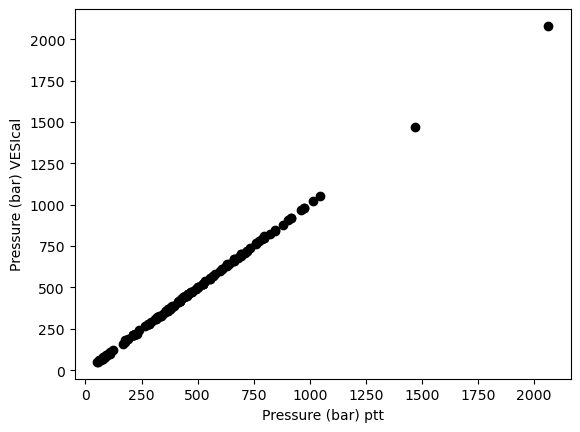

In [7]:
f, a = plt.subplots(1,1)
a.plot(fixed_T['P_bar'], Haw['SaturationP_bars_VESIcal'], 'ok')
a.set_xlabel('Pressure (bar) ptt')
a.set_ylabel('Pressure (bar) VESIcal')

We also see a reasonable match in the predicted fluid composition with some scatter at higher H2O mole fractions, the origin of this scatter we are still investigating!

Text(0, 0.5, 'X$_{H2O}$ VESIcal')

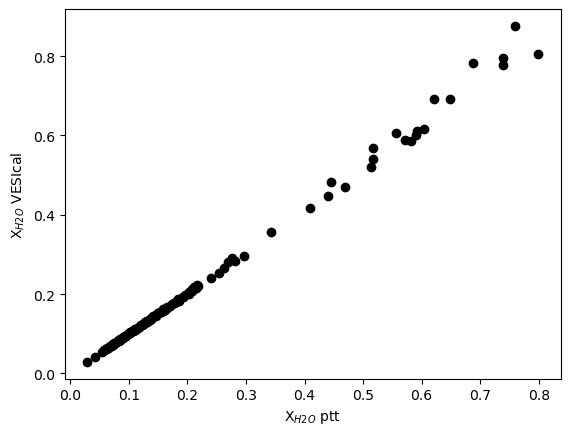

In [8]:
f, a = plt.subplots(1,1)
a.plot(fixed_T['X_H2O'], Haw['XH2O_fl_VESIcal'], 'ok')
a.set_xlabel('X$_{H2O}$ ptt')
a.set_ylabel('X$_{H2O}$ VESIcal')

### Method 2 - unknown temperature

Let's imagine you're working in an area that isn't as well studied as Hawai'i and, perhaps, you don't have an easy to use or reliable empirical thermometer to calculate the tempetature of melt inclusion entrapment. `petthermotools` provides an option for this scenario to use the rhyolite-MELTS v1.2.0 model as the thermometer as well as the barometer, meaning no prior knowledge of the system temperature is required. All that we need to change from the function above is we need to remove the key-word argument `T_fixed_C` and replace it with `T_init_C`:

In [9]:
Unknown_T = ptt.saturation_pressure(Model = "MELTSv1.2.0", bulk = Haw, T_init_C = 1100, 
                          P_init_bar = 1000)

This calculation probably took a bit longer! That's to be expected, we're having to iterate across 2 parameters not just 1. Looking at the results, however, we see that for these Hawaiian samples there is little-to-no difference in the estimated saturation pressures regardless of which method we use!

Text(0, 0.5, 'Pressure (bar) fixed T')

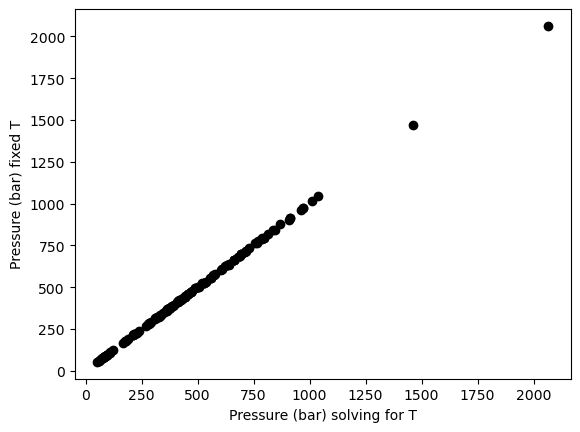

In [10]:
f, a = plt.subplots(1,1)
a.plot(Unknown_T['P_bar'], fixed_T['P_bar'], 'ok')
a.set_xlabel('Pressure (bar) solving for T')
a.set_ylabel('Pressure (bar) fixed T')

What about temperature? Well, as indicated in the liquidus calculation example, rhyolite-MELTS isn't the most accurate thermometer available. Comparing the two temperature estimates (empirical calc from Wieser et al. and the rhyolite-MELTS liquidus temperature) we can see that there is an offset between the two calculations especially at temperatures above 1200 $^o$C.

Text(0, 0.5, 'Temperature ($^o$C) fixed T (empirical calc)')

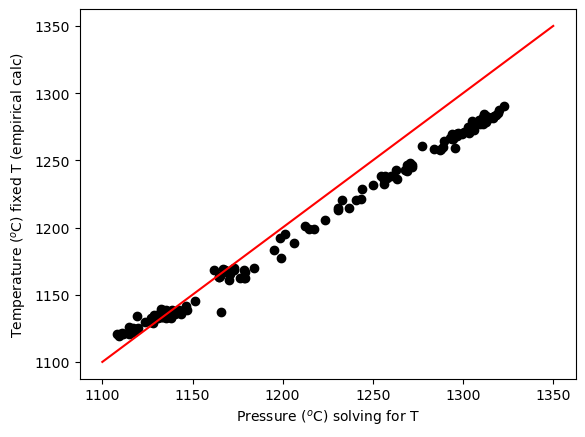

In [11]:
f, a = plt.subplots(1,1)
a.plot(Unknown_T['T_Liq_C'], fixed_T['T_Liq_C'], 'ok')
a.plot([1100,1350],[1100,1350], '-r')
a.set_xlabel('Pressure ($^o$C) solving for T')
a.set_ylabel('Temperature ($^o$C) fixed T (empirical calc)')